In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import git
import numpy as np
import magnum as mn
from PIL import Image

import habitat_sim

try:
    # For using jupyter IO components
    import IPython.display

    IS_NOTEBOOK = True

except ImportError:
    IS_NOTEBOOK = False
# [/imports]

In [2]:
os.environ["HABITAT_SIM_LOG"] = "quiet"

dir_path = "/data1/tct_data/habitat"
data_path = os.path.join(dir_path, "data")
output_directory = os.path.join(
    dir_path, "replica_cad_output/"
)  # @param {type:"string"}
os.makedirs(output_directory, exist_ok=True)

# define some constants and globals the first time we run:
opacity = 1.0
red = mn.Color4(1.0, 0.0, 0.0, opacity)
green = mn.Color4(0.0, 1.0, 0.0, opacity)
blue = mn.Color4(0.0, 0.0, 1.0, opacity)
white = mn.Color4(1.0, 1.0, 1.0, opacity)

origin = mn.Vector3(0.0, 0.0, 0.0)
eye_pos0 = mn.Vector3(2.5, 1.3, 1)
eye_pos1 = mn.Vector3(3.5, 3.0, 4.5)
obj_axes_len = 0.4

if "sim" not in globals():
    global sim
    sim = None
    global rgb_sensor_node
    rgb_sensor_node = None
    global semantic_sensor_node
    semantic_sensor_node = None
    global depth_sensor_node
    depth_sensor_node = None
    global lr
    lr = None
    global image_counter
    image_counter = 0
# [/setup]

In [3]:
def show_img(rgb_obs):
    global image_counter

    colors = []
    for row in rgb_obs:
        for rgba in row:
            colors.extend([rgba[0], rgba[1], rgba[2]])

    resolution_x = len(rgb_obs[0])
    resolution_y = len(rgb_obs)

    colors = bytes(colors)
    img = Image.frombytes("RGB", (resolution_x, resolution_y), colors)
    if IS_NOTEBOOK:
        IPython.display.display(img)
    else:
        filepath = f"{output_directory}/{image_counter}.png"
        img.save(filepath)
        print(f"Saved image: {filepath}")
        image_counter += 1

def show_scene(camera_transform):
    rgb_sensor_node.transformation = camera_transform
    semantic_sensor_node.transformation = camera_transform
    depth_sensor_node.transformation = camera_transform
    observations = sim.get_sensor_observations()
    show_img(observations["rgb"])
    # display_sample(observations["color_sensor"], observations["semantic"], observations["depth"])

def draw_axes(translation, axis_len=1.0):
    lr = sim.get_debug_line_render()
    # draw axes with x+ = red, y+ = green, z+ = blue
    lr.draw_transformed_line(translation, mn.Vector3(axis_len, 0, 0), red)
    lr.draw_transformed_line(translation, mn.Vector3(0, axis_len, 0), green)
    lr.draw_transformed_line(translation, mn.Vector3(0, 0, axis_len), blue)

def calc_camera_transform(
    eye_translation=mn.Vector3(1, 1, 1), lookat=mn.Vector3(0, 0, 0)
):
    # choose y-up to match Habitat's y-up convention
    camera_up = mn.Vector3(0.0, 1.0, 0.0)
    return mn.Matrix4.look_at(eye_translation, lookat, camera_up)

In [4]:
from agent_system.environments.env_package.habitat_sim.utils.habitat_envs import CreateHabitatEnv
from agent_system.environments.env_package.habitat_sim.utils.habitat_3dbox_utils import (
    transform_object_aabb_to_camera_obb,
    visualize_bbox_on_image,
    predict_3d_bbox,
    compute_bbox_iou_3d
)

dataset_name = "ReplicaCAD"
seed = 42
scenes_size = 10
max_scene_instance = 20
max_step_length = 10

env = CreateHabitatEnv(seed, dataset_name, scenes_size, max_scene_instance, max_step_length)
    

2025-11-07 21:16:34,355	INFO worker.py:1942 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


(raylet) [2025-11-07 21:16:44,225 E 1537697 1537723] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-11-07_21-16-16_672309_1536501 is over 95% full, available space: 3.24849 GB; capacity: 438.051 GB. Object creation will fail if spilling is required.
(raylet) [2025-11-07 21:16:54,233 E 1537697 1537723] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-11-07_21-16-16_672309_1536501 is over 95% full, available space: 3.24847 GB; capacity: 438.051 GB. Object creation will fail if spilling is required.
(raylet) [2025-11-07 21:17:04,244 E 1537697 1537723] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-11-07_21-16-16_672309_1536501 is over 95% full, available space: 3.24846 GB; capacity: 438.051 GB. Object creation will fail if spilling is required.
(raylet) [2025-11-07 21:17:14,254 E 1537697 1537723] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-11-07_21-16-16_672309_1536501 is over 95% full, available space: 3.24845 GB; capacity: 438.051 GB. Obj

In [5]:
import json
def load_task_by_id(json_file, task_id):
    """从 JSON 文件中加载指定 task_id 的任务"""
    with open(json_file, 'r', encoding='utf-8') as f:
        all_tasks = json.load(f)
    
    for task in all_tasks:
        if task.get('task_id') == task_id:
            return task
    
    raise ValueError(f"Task with task_id={task_id} not found in {json_file}")

json_file = "/data1/tct_data/habitat/eval_data/replicacad_10-segment/task_infos.json"
task_id = 14
task_info = load_task_by_id(json_file, task_id)
obs, info = env.reset_eval(sync_info=task_info)
sim = env.sim

Renderer: NVIDIA GeForce RTX 4090/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 535.183.01
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
Grounding-Segment pipeline error: HTTPConnectionPoo

MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its biding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its biding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its biding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its biding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0


In [6]:
print(task_info)

{'task_id': 14, 'task_type': 'segment', 'target_category': 'tv_screen', 'semantic_id': 87, 'instance_id': 3, 'obj_handle': '/data1/tct_data/habitat/data/replica_cad/configs/objects/frl_apartment_tv_screen.object_config.json', 'obj_rotation': [1.8966080972404598e-07, 0.7077053189277649, -1.6858739115832577e-07, 0.7065077424049377], 'obj_translation': [4.383266448974609, 1.7835476398468018, 4.519914627075195], 'gt': {'bbox_gt': [350, 419, 106, 235], 'mask_gt': {'size': [512, 512], 'counts': ']S_5]3c<001N100O101N11O15KO100O1O1O1O103L001O1O1O100O1O1O1O100O1O1O1O100O1O001O100O1O1O1O100O1O1O1O100O1O1O1O00100O1O1O1O100O1O1O1O1O1O1L211O1O1Ojj]1'}}, 'task_prompt': 'tv screen on wall', 'conf_score': 0.8513632714748383, 'phi': 0.5786881196206929, 'scene_id': '/data1/tct_data/habitat/data/replica_cad/configs/scenes/v3_sc3_staging_18.scene_instance.json', 'agent_pos': {'coords': [3.51291561126709, 0.11094765365123749, 1.767642617225647], 'rotation': 3.931495871147228}}


In [7]:
rigid_obj_mgr = sim.get_rigid_object_manager()

In [8]:
object_id = task_info["instance_id"]
obj = rigid_obj_mgr.get_object_by_id(object_id)

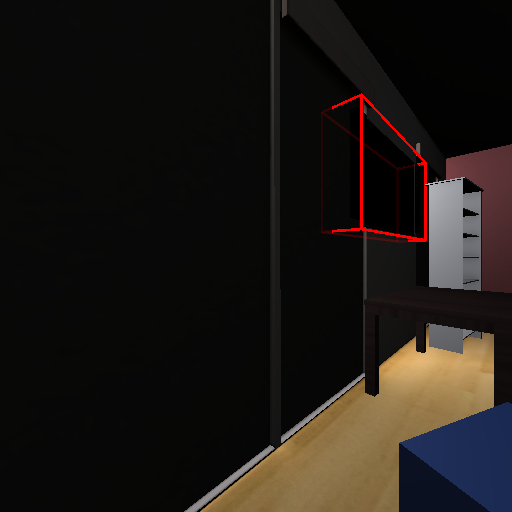

In [9]:
lr = sim.get_debug_line_render()
lr.push_transform(obj.transformation)
lr.draw_box(obj.collision_shape_aabb.min, obj.collision_shape_aabb.max, red)
lr.pop_transform()

observations = sim.get_sensor_observations()
show_img(observations["rgb"])


=== 转换物体AABB到相机坐标系OBB ===
OBB中心（相机坐标系）: [ 1.30560681  0.66774189 -2.59151955]
OBB尺寸: [1.88474262 0.95288187 0.31589328]
OBB半长度: [0.94237131 0.47644094 0.15794664]
OBB主轴方向:
[[-7.09092001e-01 -3.35784871e-07 -7.05115972e-01]
 [ 3.02313338e-08  1.00000000e+00 -5.06614013e-07]
 [ 7.05115972e-01 -3.80552593e-07 -7.09092001e-01]]

显示带有OBB可视化的图像...


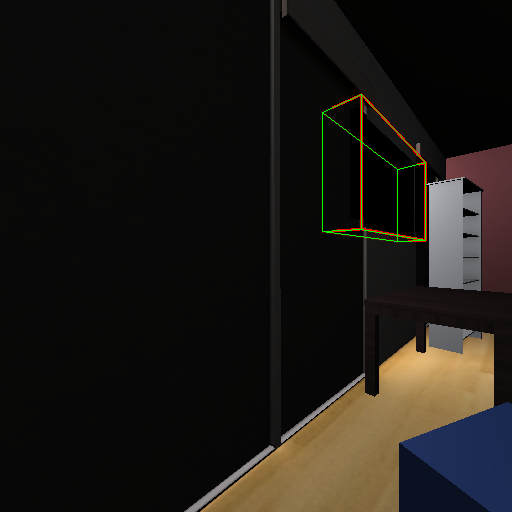

In [10]:
# 方法2：将物体AABB转换到相机坐标系的OBB，并在2D图像上可视化
print("\n=== 转换物体AABB到相机坐标系OBB ===")
agent = sim.get_agent(0)
agent_state = agent.get_state()

# 转换物体坐标系下的AABB到相机坐标系下的OBB
bbox_camera_obb = transform_object_aabb_to_camera_obb(obj, agent_state, sensor_name='rgb')

print(f"OBB中心（相机坐标系）: {bbox_camera_obb['obb_center']}")
print(f"OBB尺寸: {bbox_camera_obb['size']}")
print(f"OBB半长度: {bbox_camera_obb['obb_extents']}")
print(f"OBB主轴方向:\n{bbox_camera_obb['obb_axes']}")

# 在图像上可视化OBB（使用obb_corners）
rgb_image = observations["rgb"][:, :, :3]  # 去掉alpha通道
image_with_obb = visualize_bbox_on_image(
    rgb_image, 
    bbox_camera_obb, 
    hfov=90.0, 
    color=(0, 255, 0),  # 绿色
    thickness=1,
    use_obb=True
)

# 显示带有OBB的图像
print("\n显示带有OBB可视化的图像...")
show_img(image_with_obb)

In [14]:
predicted_bbox, _ = predict_3d_bbox(
    observations["semantic"], 
    observations["depth"], 
    task_info["semantic_id"], 
    agent_state, 
    hfov=90.0, 
    return_world_coords=False
    )
iou = compute_bbox_iou_3d(bbox_camera_obb, predicted_bbox, use_obb=True)
print(iou)

0.0


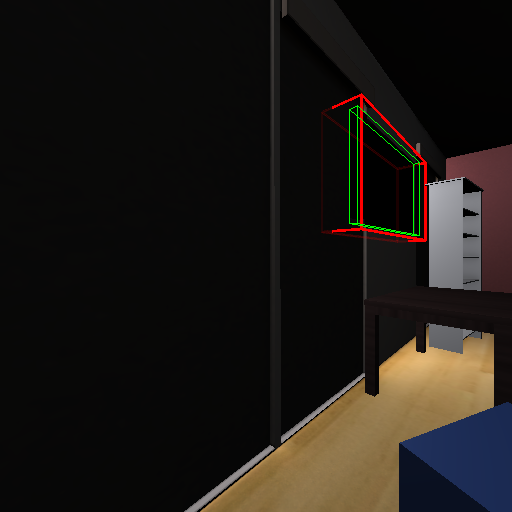

In [12]:
img = visualize_bbox_on_image(observations["rgb"], predicted_bbox, hfov=90.0, color=(0, 255, 0), thickness=1, use_obb=True)
show_img(img)